# Cycle 2: a measured CatBoost pipeline

We predict the **total posted freight price in dollars**, one row per load. This notebook turns the exploration into a reproducible first model: split the labeled data, learn preprocessing only from the training rows, select CatBoost settings on a development set, and measure the frozen choice on a later local test set.

The original CSVs stay unchanged. Negative weights become positive inside the pipeline; missing numerical values remain `NaN`. The saved pipeline accepts raw input rows, so the same rules are applied during training and prediction.

**Important distinction:** `train-test.csv` is the labeled dataset we split here. `validation.csv` is the external November–December input file with hidden targets; its accuracy cannot be measured locally. The September–October local test set was previously visible during exploration, so it is held out from model fitting and selection, but is not completely untouched by prior analysis.

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Locate the repository whether Jupyter starts at its root or in notebooks/.
ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents]
     if (path / "freight_model.py").exists() and (path / "train-test.csv").exists()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the spotter project.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from freight_model import (
    CANDIDATES, CORE_COLUMNS, COORDINATES, FreightPreprocessor,
    source_hashes, load_development, split_development, split_summary,
    select_on_dev, refit_and_evaluate, save_results,
)

OUTPUT = ROOT / "outputs" / "catboost"
OUTPUT.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
COLORS = {"CatBoost": "#007f86", "Baseline": "#b98232"}
pd.set_option("display.max_columns", 20)
original_hashes = source_hashes(ROOT)
raw = load_development(ROOT)
print(f"Loaded {len(raw):,} labeled loads. Source CSV hashes recorded.")

Loaded 48,000 labeled loads. Source CSV hashes recorded.


## 1. Split before fitting anything

A random split can put later loads into training while we evaluate earlier ones. Our actual task predicts future months, so we preserve time order:

| Part | Period | Purpose |
|---|---|---|
| Train | January–June 2025 | Learn preprocessing, the baseline, and candidate CatBoost models |
| Development (`dev`) | July–August 2025 | Choose settings and the number of boosting trees |
| Local test | September–October 2025 | Measure the locked choice after a January–August refit |

The boundaries are fixed **before** training. A row belongs to exactly one part. No September–October targets are used for preprocessing, early stopping, or choosing the candidate. After selection, reusing the dev rows for the final refit is valid because the later test rows remain excluded. Once we inspect test results, using them to make new model choices would turn this test set into another development set.

See scikit-learn's [data leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) for why learned preprocessing belongs inside the training process.

In [2]:
splits = split_development(raw)
split_table = split_summary(splits)
display(split_table)

# Split assignments contain identifiers and dates only; they make this run reproducible.
assert sum(len(part) for part in splits.values()) == len(raw)
assert splits["train"]["date"].max() < splits["dev"]["date"].min()
assert splits["dev"]["date"].max() < splits["test"]["date"].min()
assert set(splits["train"]["load_id"]).isdisjoint(splits["dev"]["load_id"])
assert set(splits["train"]["load_id"]).isdisjoint(splits["test"]["load_id"])
assert set(splits["dev"]["load_id"]).isdisjoint(splits["test"]["load_id"])

,split,rows,percent,first_date,last_date,missing_weight,negative_weight
0,train,28806,60.012500,2025-01-01,2025-06-30,177,196
1,dev,9671,20.147917,2025-07-01,2025-08-31,58,37
2,test,9523,19.839583,2025-09-01,2025-10-31,65,59


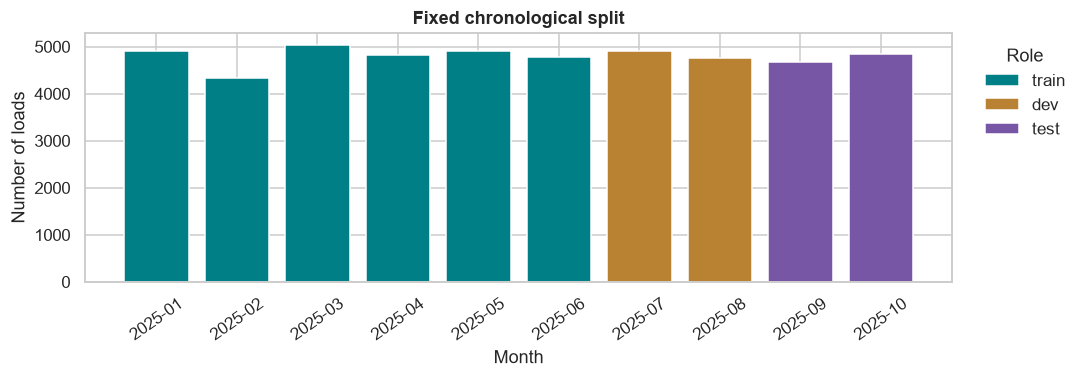

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.6))
split_colors = {"train": "#007f86", "dev": "#b98232", "test": "#7757a5"}
for name, part in splits.items():
    counts = part.groupby(part["date"].dt.to_period("M")).size()
    ax.bar(counts.index.astype(str), counts.values, color=split_colors[name], label=name)
ax.set(title="Fixed chronological split", xlabel="Month", ylabel="Number of loads")
ax.legend(title="Role", loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
fig.savefig(OUTPUT / "chronological_split.png", dpi=160, bbox_inches="tight")
plt.show()

## 2. Features and preprocessing

The `FreightPreprocessor` in `freight_model.py` is the single source of preprocessing rules. It returns a new DataFrame instead of changing the source data.

| Input | Treatment | Reason |
|---|---|---|
| Pickup, delivery, equipment | Categorical strings; an explicit label for missing categories | Let CatBoost learn category effects without assigning arbitrary ordered numbers |
| Distance | Keep the provided positive mileage | Trip length is directly useful for predicting total price |
| Weight | Absolute value; retain missing values | Apply our agreed sign correction without inventing a missing weight |
| Weight flags | Add `weight_is_missing` and `weight_was_negative` | Preserve whether a value was absent or its sign was corrected |
| Four coordinate columns | Keep latitude and longitude separately, including valid negative longitudes | Preserve origin and destination geography |
| Missing coordinate columns | Look up cities using only the rows used to fit this preprocessor | Support the reduced December schema; unknown cities remain `NaN` |
| Date | Days since the training start, day of week, and day of month | Represent time and recurring calendar effects numerically |
| `load_id` | Exclude from features | Identifier used to track rows |
| `posted_rate` / `predicted_rate` | Exclude from features | The training label / an output placeholder, never a predictor |
| `market_index`, `quote_signal` | Exclude from this first model | They are absent from the December input schema; `quote_signal` also showed unstable monthly relationships |

CatBoost handles numerical `NaN` values natively. We use its `Min` mode, which gives missing values an explicit position for tree splits; this is **not** filling them with a real minimum weight. Categorical missing values are handled separately as strings. See [CatBoost missing-value processing](https://catboost.ai/docs/en/concepts/algorithm-missing-values-processing).

There is no numerical scaling or median imputation in this pipeline. City-to-coordinate lookup and the time origin are learned only on the applicable training rows. The target stays in raw total dollars; we do not train on price per mile or log price in this first cycle.

In [4]:
# This preview is fitted only on January–June, after the split.
preview_preprocessor = FreightPreprocessor().fit(splits["train"])
train_features = preview_preprocessor.transform(splits["train"])
feature_audit = pd.DataFrame({
    "type": train_features.dtypes.astype(str),
    "missing_train_rows": train_features.isna().sum(),
})
display(feature_audit)
display(train_features.head(5))

assert "posted_rate" not in train_features
assert "load_id" not in train_features
assert "market_index" not in train_features
assert "quote_signal" not in train_features
assert not train_features["weight"].dropna().lt(0).any()
assert train_features["weight"].isna().equals(splits["train"]["weight"].isna())
print(f"The model receives {train_features.shape[1]} features.")

,type,missing_train_rows
pickup,object,0
delivery,object,0
equipment,object,0
distance,float64,0
weight,float64,177
weight_is_missing,int64,0
weight_was_negative,int64,0
pickup_lat,float64,0
pickup_lon,float64,0
delivery_lat,float64,0


,pickup,delivery,equipment,distance,weight,weight_is_missing,weight_was_negative,pickup_lat,pickup_lon,delivery_lat,delivery_lon,days_since_start,day_of_week,day_of_month
0,Richmond,Baltimore,Dry Van,274.3,30658.0,0,0,38.09122,-76.78906,38.16908,-72.74564,0,2,1
1,Richmond,Philadelphia,Reefer,280.5,17555.0,0,0,38.09122,-76.78906,39.22317,-72.96710,0,2,1
2,Philadelphia,Green Bay,Dry Van,967.8,31721.0,0,0,39.22317,-72.96710,44.30296,-87.52871,0,2,1
3,Hartford,Atlanta,Dry Van,965.4,32333.0,0,0,39.55328,-72.18051,34.84933,-86.28940,0,2,1
4,Dallas,Nashville,Reefer,541.9,35183.0,0,0,31.83025,-94.38343,35.29479,-88.08915,0,2,1


The model receives 14 features.


## 3. Baseline and a small, explicit candidate search

The baseline learns each equipment type's **median price per mile** from training rows, then multiplies it by each new load's distance. An unseen equipment type falls back to the training-wide median. This is a simple reference the model should improve upon.

We try three CatBoost candidates. **Development MAE chooses among the CatBoost candidates**, and the baseline remains visible for comparison even if it wins. MAE is the average absolute dollar mistake per load; choosing it makes our selection goal easy to interpret.

| Choice | Value | Why start here? |
|---|---|---|
| Maximum trees | 1,200 | A bounded training budget; early stopping can choose fewer |
| Learning rate | 0.05 | Modest updates per tree; paired with the tree budget |
| Tree depth | 6 or 8 | Compare moderate and higher interaction complexity |
| Training loss | MAE or RMSE | Compare direct absolute-error fitting with a loss that penalizes large errors more strongly |
| Early-stopping patience | 100 trees | Allow a run of non-improving iterations before stopping |
| L2 leaf regularization | 3 | A fixed starting value to limit the size of the first search |
| Random seed | 42 | Reproducibility |

These are practical starting choices, **not proven optimal values**. All candidates use the same inputs and split. The dev set is passed to CatBoost as `eval_set`, and the retained tree count is selected by dev MAE. The chronological input order is retained with `has_time=True`. See CatBoost's [fit parameters](https://catboost.ai/docs/en/concepts/python-reference_catboostregressor_fit).

A fixed positive floor of USD 0.01 is applied to predictions because freight rates must be positive. Its use is included in measurement, and we report how often it is needed.

In [5]:
display(pd.DataFrame(CANDIDATES))
# This function never uses the test set for fitting or early stopping.
selection = select_on_dev(splits, max_iterations=1200, patience=100)
display(selection["leaderboard"].round(3))
print(f"Selected CatBoost candidate: {selection['best_name']}")
print(f"Selected tree count: {selection['best_trees']:,}")

best_dev = selection["leaderboard"].set_index("model").loc[selection["best_name"]]
baseline_dev = selection["leaderboard"].set_index("model").loc["Equipment median baseline"]
dev_improvement = 100 * (1 - best_dev["MAE"] / baseline_dev["MAE"])
comparison_word = "lower" if dev_improvement >= 0 else "higher"
display(Markdown(
    f"The selected CatBoost has **dev MAE = USD {best_dev['MAE']:,.2f}**, "
    f"which is **{abs(dev_improvement):.1f}% {comparison_word}** than the baseline. "
    "This dev result helped choose the model, so the later test measurement is the next check."
))

,name,depth,loss_function
0,CatBoost depth 6 MAE,6,MAE
1,CatBoost depth 8 MAE,8,MAE
2,CatBoost depth 6 RMSE,6,RMSE


CatBoost depth 6 MAE: dev MAE=$155.66, 94 trees, 28.3s


CatBoost depth 8 MAE: dev MAE=$163.20, 90 trees, 37.1s


CatBoost depth 6 RMSE: dev MAE=$186.62, 65 trees, 23.2s


,model,trees,seconds,MAE,RMSE,R2,bias,median_absolute_error
0,CatBoost depth 6 MAE,94,28.284,155.659,627.943,0.823,51.361,80.490
1,CatBoost depth 8 MAE,90,37.063,163.203,629.037,0.822,64.760,87.818
2,CatBoost depth 6 RMSE,65,23.155,186.616,632.882,0.820,84.635,122.178
3,Equipment median baseline,0,0.000,222.731,662.875,0.802,40.758,113.270


Selected CatBoost candidate: CatBoost depth 6 MAE
Selected tree count: 94


The selected CatBoost has **dev MAE = USD 155.66**, which is **30.1% lower** than the baseline. This dev result helped choose the model, so the later test measurement is the next check.

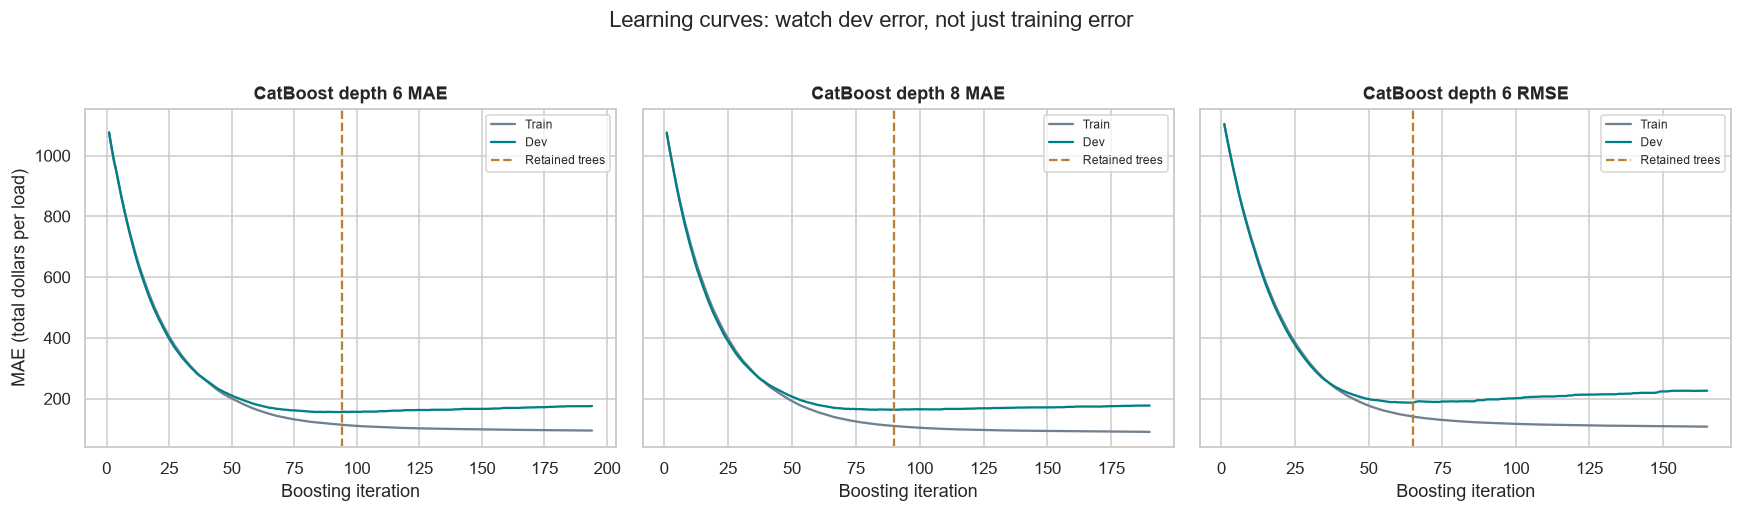

In [6]:
# Each point is a training iteration; lower MAE is better.
fig, axes = plt.subplots(1, len(selection["histories"]), figsize=(16, 4.5), sharey=True)
for ax, (name, history) in zip(np.atleast_1d(axes), selection["histories"].items()):
    train_mae = history["learn"]["MAE"]
    dev_mae = history["validation"]["MAE"]
    ax.plot(np.arange(1, len(train_mae) + 1), train_mae, label="Train", color="#71808f")
    ax.plot(np.arange(1, len(dev_mae) + 1), dev_mae, label="Dev", color=COLORS["CatBoost"])
    retained = selection["pipelines"][name].named_steps["model"].tree_count_
    ax.axvline(retained, color="#b98232", linestyle="--", label="Retained trees")
    ax.set(title=name, xlabel="Boosting iteration")
    ax.legend(fontsize=8)
axes[0].set_ylabel("MAE (total dollars per load)")
fig.suptitle("Learning curves: watch dev error, not just training error", y=1.03)
fig.tight_layout()
fig.savefig(OUTPUT / "learning_curves.png", dpi=160, bbox_inches="tight")
plt.show()

A falling training curve only shows that the model is fitting the rows it learns from. If the dev curve stops improving while the training curve keeps falling, more trees are not helping future-month prediction. The dashed line shows the retained tree count; the recorded history can extend beyond it because early stopping waits for the patience window.

## 4. Freeze the choice, refit, and measure once on the local test

We now fix the chosen candidate and tree count. We refit preprocessing, CatBoost, and the baseline on **January–August**. The test set is not passed as an `eval_set`, and it does not choose the number of trees.

Metric meanings:

- **MAE:** average size of the dollar mistake, ignoring its direction. Lower is better.
- **RMSE:** another dollar error measure that gives large mistakes more influence. Lower is better.
- **R²:** 1 means perfect predictions; 0 matches predicting the test target's mean; a negative result is worse than that reference.
- **Bias:** average `prediction - actual`. Positive means overprediction; negative means underprediction. A near-zero bias can still hide large offsetting errors.
- **Median absolute error:** half the loads have an absolute error at or below this value.
- **MAE improvement:** percentage reduction relative to the baseline. Negative values mean CatBoost lost to the baseline.

In [7]:
# Keep this selection fixed when interpreting the following test results.
locked_choice = (selection["best_name"], selection["best_trees"])
evaluation = refit_and_evaluate(splits, selection)
assert locked_choice == (selection["best_name"], selection["best_trees"])
display(evaluation["test_metrics"].round(3))

scores = evaluation["test_metrics"].set_index("model")
model_score = scores.loc[selection["best_name"]]
baseline_score = scores.loc["Equipment median baseline"]
improvement = model_score["MAE_improvement_percent"]
comparison_word = "lower" if improvement >= 0 else "higher"
bias_word = "overpredicts" if model_score["bias"] >= 0 else "underpredicts"
display(Markdown(
    f"On **{len(splits['test']):,} September–October loads**, the frozen CatBoost choice "
    f"has an average absolute mistake of **USD {model_score['MAE']:,.2f} per load**. "
    f"Its MAE is **{abs(improvement):.1f}% {comparison_word}** than the baseline. "
    f"RMSE is **USD {model_score['RMSE']:,.2f}** and R² is **{model_score['R2']:.3f}**. "
    f"It {bias_word} by **USD {abs(model_score['bias']):,.2f} on average**. "
    f"The positive prediction floor affected **{evaluation['positive_floor_count']:,}** test predictions."
))
print(f"The measured model learned from {evaluation['fit_rows']:,} rows through {evaluation['fit_end']}.")

,model,MAE,RMSE,R2,bias,median_absolute_error,MAE_improvement_percent
0,Equipment median baseline,229.097,670.660,0.807,40.929,115.716,0.000
1,CatBoost depth 6 MAE,128.077,643.243,0.822,-67.037,42.521,44.095


On **9,523 September–October loads**, the frozen CatBoost choice has an average absolute mistake of **USD 128.08 per load**. Its MAE is **44.1% lower** than the baseline. RMSE is **USD 643.24** and R² is **0.822**. It underpredicts by **USD 67.04 on average**. The positive prediction floor affected **0** test predictions.

The measured model learned from 38,477 rows through 2025-08-31.


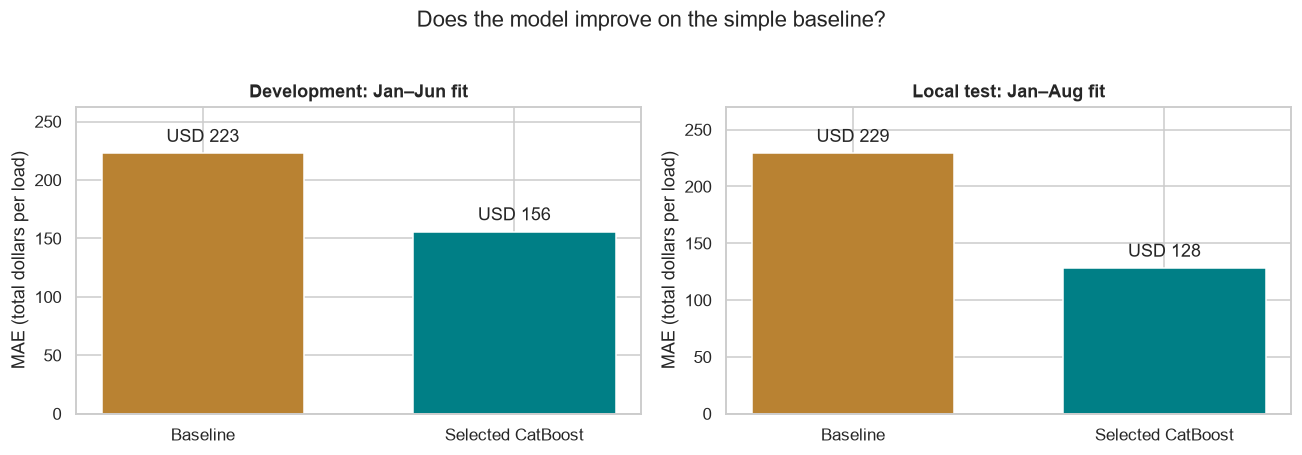

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparisons = [
    ("Development: Jan–Jun fit", selection["leaderboard"].set_index("model")),
    ("Local test: Jan–Aug fit", evaluation["test_metrics"].set_index("model")),
]
for ax, (title, table) in zip(axes, comparisons):
    values = [table.loc["Equipment median baseline", "MAE"], table.loc[selection["best_name"], "MAE"]]
    bars = ax.bar(["Baseline", "Selected CatBoost"], values,
                  color=[COLORS["Baseline"], COLORS["CatBoost"]], width=0.65)
    ax.bar_label(bars, labels=[f"USD {value:,.0f}" for value in values], padding=5)
    ax.set(title=title, ylabel="MAE (total dollars per load)", ylim=(0, max(values) * 1.18))
fig.suptitle("Does the model improve on the simple baseline?", y=1.03)
fig.tight_layout()
fig.savefig(OUTPUT / "baseline_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Inspect errors, not only one average

All plots below use the already measured test predictions; they do not fit or tune another model. Predictions on the diagonal in the first chart are correct. Points below it are underpredictions. Extreme prices remain included in all reported metrics.

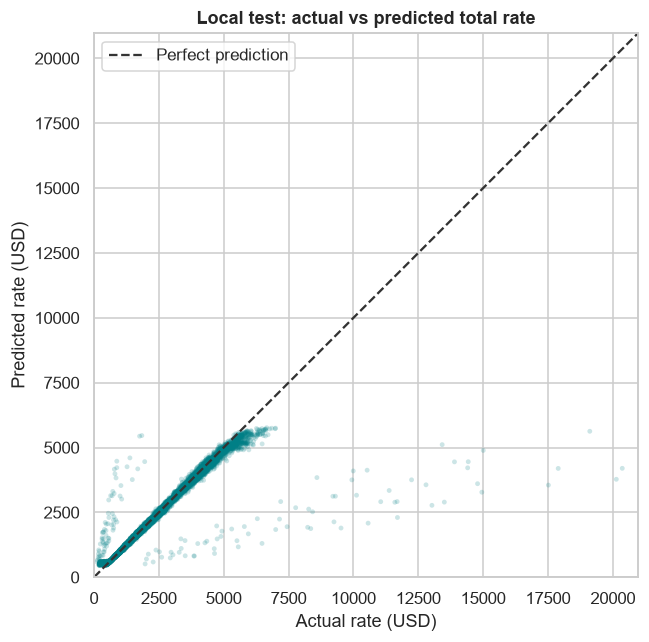

In [9]:
details = evaluation["test_predictions"].copy()
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(details["posted_rate"], details["predicted_rate"], s=10, alpha=0.20,
           color=COLORS["CatBoost"], edgecolors="none", rasterized=True)
upper = max(details["posted_rate"].max(), details["predicted_rate"].max()) * 1.03
ax.plot([0, upper], [0, upper], linestyle="--", color="#333333", label="Perfect prediction")
ax.set(title="Local test: actual vs predicted total rate", xlabel="Actual rate (USD)",
       ylabel="Predicted rate (USD)", xlim=(0, upper), ylim=(0, upper))
ax.set_aspect("equal", adjustable="box")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT / "actual_vs_predicted.png", dpi=160, bbox_inches="tight")
plt.show()

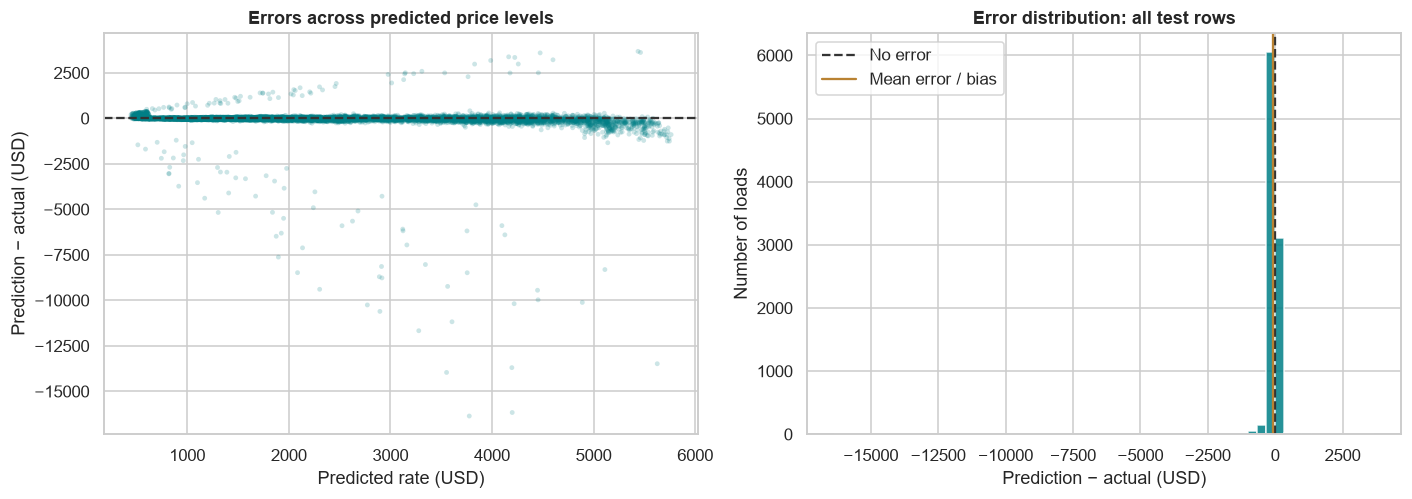

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
axes[0].scatter(details["predicted_rate"], details["error"], s=10, alpha=0.20,
                color=COLORS["CatBoost"], edgecolors="none", rasterized=True)
axes[0].axhline(0, linestyle="--", color="#333333")
axes[0].set(title="Errors across predicted price levels", xlabel="Predicted rate (USD)",
            ylabel="Prediction − actual (USD)")
axes[1].hist(details["error"], bins=60, color=COLORS["CatBoost"], alpha=0.85)
axes[1].axvline(0, linestyle="--", color="#333333", label="No error")
axes[1].axvline(details["error"].mean(), color=COLORS["Baseline"], label="Mean error / bias")
axes[1].set(title="Error distribution: all test rows", xlabel="Prediction − actual (USD)",
            ylabel="Number of loads")
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT / "residual_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()

The residual plots show direction and spread. We want errors reasonably balanced around zero; large tails explain why RMSE can be much larger than MAE. A pattern can suggest a weakness, but it does not establish its cause. This cycle records the evidence without changing the model to improve the observed test score.

The next table measures predefined groups. **Check the row count:** an error average from a small group is less stable. Distance bins (0–250, 250–750, 750–1,500, and 1,500+ miles) are readable reporting bands, not fitted decision boundaries. "Unseen lane" means that the ordered pickup–delivery pair was absent from the January–August fitting rows.

,dimension,group,rows,MAE,RMSE,R2,bias,median_absolute_error,baseline_MAE,MAE_improvement_percent
0,month,2025-09,4670,125.652,627.148,0.831,-65.311,42.981,227.323,44.725
1,month,2025-10,4853,130.410,658.359,0.814,-68.698,41.956,230.803,43.497
2,equipment,Dry Van,5360,120.955,662.857,0.797,-59.843,36.560,225.173,46.283
3,equipment,Flatbed,1770,122.570,515.695,0.884,-51.359,50.134,218.107,43.803
4,equipment,Reefer,2393,148.101,682.434,0.823,-94.746,54.416,246.013,39.799
5,distance_miles,0-250,550,98.630,167.336,-0.012,77.226,42.479,114.883,14.148
6,distance_miles,250-750,3040,59.122,275.012,0.511,-27.207,24.906,130.793,54.797
7,distance_miles,750-1500,3232,110.564,590.992,0.341,-57.025,45.504,138.876,20.386
8,distance_miles,1500+,2701,232.639,974.705,0.370,-153.222,93.138,470.953,50.603
9,missing_weight,missing,65,120.929,170.084,0.986,-102.790,86.672,182.762,33.833


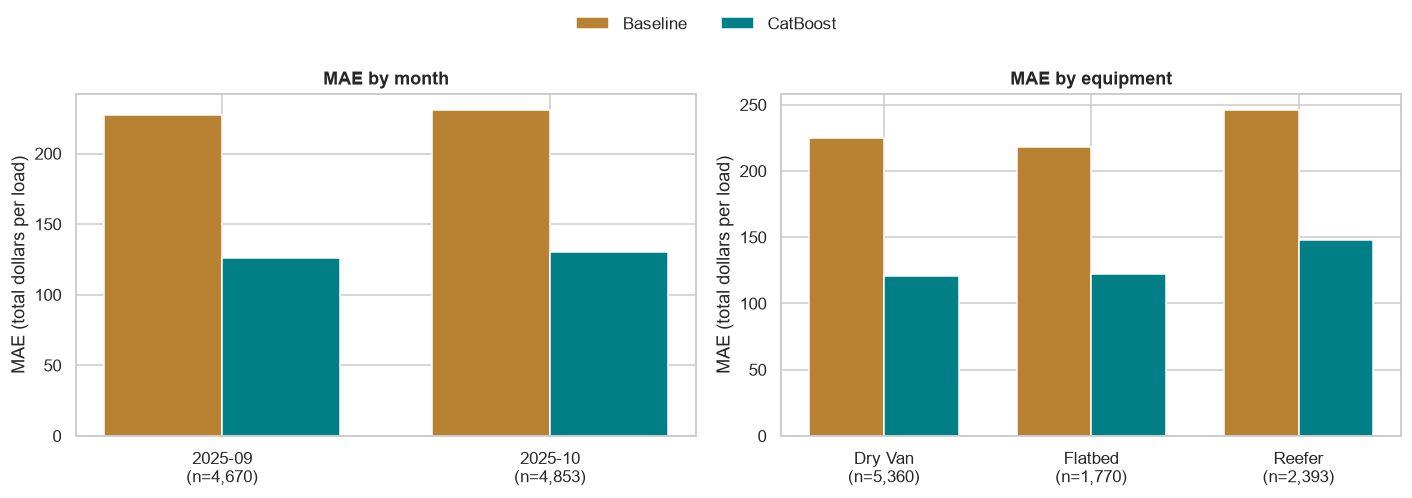

In [11]:
display(evaluation["slice_metrics"].round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, dimension, title in zip(axes, ["month", "equipment"], ["MAE by month", "MAE by equipment"]):
    part = evaluation["slice_metrics"].query("dimension == @dimension").reset_index(drop=True)
    positions = np.arange(len(part))
    ax.bar(positions - 0.18, part["baseline_MAE"], width=0.36,
           color=COLORS["Baseline"], label="Baseline")
    ax.bar(positions + 0.18, part["MAE"], width=0.36,
           color=COLORS["CatBoost"], label="CatBoost")
    ax.set_xticks(positions, [f"{group}\n(n={rows:,})" for group, rows in zip(part["group"], part["rows"])])
    ax.set(title=title, ylabel="MAE (total dollars per load)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncols=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(OUTPUT / "mae_by_month_and_equipment.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Which features did this fitted model use?

CatBoost's importance values summarize how strongly features contributed to predictions in this fitted model. They are not the percentage of price "caused" by a feature, and they do not prove a business mechanism. Related inputs can share importance: city names and coordinates, for example, both describe geography. Importance alone is not enough to decide that a feature should be removed.

,feature,importance
3,distance,92.313
2,equipment,3.569
11,days_since_start,1.236
8,pickup_lon,0.974
4,weight,0.701
9,delivery_lat,0.480
7,pickup_lat,0.400
10,delivery_lon,0.265
12,day_of_week,0.031
13,day_of_month,0.016


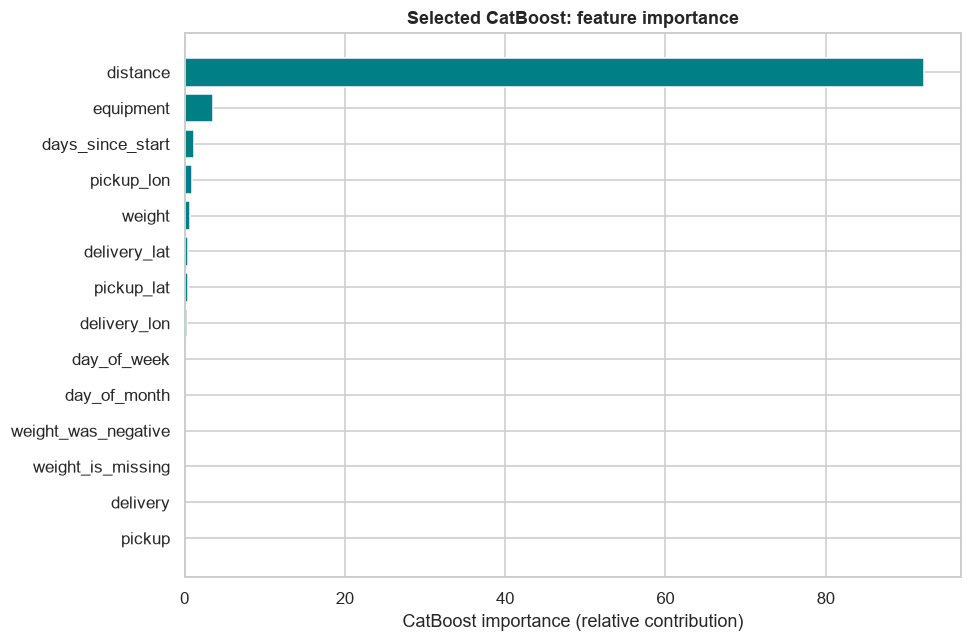

In [12]:
importance = evaluation["feature_importance"].copy()
display(importance.round(3))
plot_importance = importance.sort_values("importance")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_importance["feature"], plot_importance["importance"], color=COLORS["CatBoost"])
ax.set(title="Selected CatBoost: feature importance", xlabel="CatBoost importance (relative contribution)",
       ylabel="")
fig.tight_layout()
fig.savefig(OUTPUT / "feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Save the measured pipeline and reproduce raw-row inference

The saved artifact includes the fitted preprocessor and CatBoost model. It was trained on January–August, matching the test results above; we do not silently replace it with a model trained on all labeled data. `save_results` writes split assignments, dev/test metrics and predictions, slice results, feature importance, learning curves, and metadata, then reloads the saved artifact and checks its predictions.

The CSVs written under `outputs/catboost/` are **new result files**. The supplied CSVs are checked by SHA-256 hashes and never overwritten. Load joblib artifacts only from a trusted source; the artifact below was created by this run.

In [13]:
metadata = save_results(ROOT, OUTPUT, splits, selection, evaluation, original_hashes)
saved_pipeline = joblib.load(OUTPUT / "catboost_pipeline.joblib")

# Demonstrate prediction from raw inputs, without the target or precomputed features.
example_rows = splits["test"].head(5)
example_raw_inputs = example_rows[CORE_COLUMNS + COORDINATES].copy()
example_predictions = saved_pipeline.predict(example_raw_inputs)
np.testing.assert_allclose(
    example_predictions,
    evaluation["test_predictions"].head(5)["predicted_rate"].to_numpy(),
    rtol=0, atol=1e-10,
)
display(example_rows[["load_id", "posted_rate"]].assign(predicted_rate=example_predictions))
print(f"Saved and reloaded: {OUTPUT / 'catboost_pipeline.joblib'}")
print(f"Model fit ends: {metadata['saved_model_fit_end']}")

,load_id,posted_rate,predicted_rate
38477,TR-038478,323.23,500.652460
38478,TR-038479,1264.20,1320.632606
38479,TR-038480,1203.42,1228.736340
38480,TR-038481,1478.30,1512.997733
38481,TR-038482,2311.83,2285.206339


Saved and reloaded: C:\Users\default.LAPTOP-H1OG6SJ2\Desktop\Projects\spotter\outputs\catboost\catboost_pipeline.joblib
Model fit ends: 2025-08-31


## 8. Check the reduced December input schema

The December file has the core six inputs but no coordinates or market/quote signals. Our pipeline can fill coordinates for its cities using the **January–August training lookup**. If a new city has no supplied coordinates and is absent from that lookup, coordinates remain missing; CatBoost can still receive the row, but this does not guarantee good accuracy.

This is an input-compatibility smoke check, not a December accuracy measurement. We do not write a submission file or fill either prediction template here. The existing December `predicted_rate` placeholder is deliberately excluded from the inputs.

In [14]:
december_raw = pd.read_csv(ROOT / "december-chart-inputs.csv", parse_dates=["date"])
december_inputs = december_raw[CORE_COLUMNS].copy()
december_features = saved_pipeline.named_steps["features"].transform(december_inputs)
december_smoke_predictions = saved_pipeline.predict(december_inputs)
assert len(december_smoke_predictions) == len(december_inputs)
assert np.isfinite(december_smoke_predictions).all()
assert (december_smoke_predictions > 0).all()
assert december_features[COORDINATES].notna().all().all(), "Expected known fixed-lane cities in the training lookup."

display(pd.concat([
    december_inputs[["pickup", "delivery"]], december_features[COORDINATES]
], axis=1).drop_duplicates())
print(f"Reduced-schema smoke check passed for {len(december_inputs):,} December rows.")
print("No final prediction file was created or changed.")
assert source_hashes(ROOT) == original_hashes, "A supplied CSV changed during the run."
print("All four supplied CSV files match their original SHA-256 hashes.")

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon
0,Lexington,Fort Wayne,36.99152,-84.99876,41.31561,-85.36206


Reduced-schema smoke check passed for 31 December rows.
No final prediction file was created or changed.
All four supplied CSV files match their original SHA-256 hashes.


## 9. What this first cycle establishes—and what remains uncertain

We now have a complete, reproducible training and prediction path plus a chronological measurement against a baseline. The measured result is specific to the stated split and features.

- **Prior exploration:** September–October was seen during Cycle 1 analysis. It was excluded from model fitting and candidate selection here, but it is not a pristine holdout from the whole project history.
- **Unseen cities:** a successful prediction call for an unseen category is not evidence of accuracy. The local test's coverage is reported below; without unseen-city rows, it cannot measure that part of the external task.
- **Future dates:** boosted trees partition feature values. An ordinal time feature does not let them continue a trend indefinitely beyond the fitted time range. Weekday/day-of-month patterns may vary predictions, but they do not solve a new market regime.
- **Missing inputs:** native `NaN` handling is a starting approach. The slice table shows missing-weight performance; small groups require cautious interpretation.
- **No guaranteed external score:** November–December prices are hidden, and the final inputs differ from local history. We cannot report their accuracy.
- **Further experiments:** comparing other time windows, feature sets, or missing-value treatments is future development work. Do not repeatedly choose changes from this same local test score and continue calling it an untouched test.

The stored model is the measured January–August refit. Training a later submission model on all labeled rows should be a separate, explicit step after the final configuration is locked.

In [15]:
unseen_count = int(details["unseen_city"].sum())
if unseen_count == 0:
    display(Markdown(
        "**Local test coverage:** all test cities occurred in the January–August fitting rows. "
        "Unseen-city accuracy is therefore **not measured** by this test."
    ))
else:
    display(Markdown(f"**Local test coverage:** {unseen_count:,} rows involve an unseen city; inspect the city-status slice above."))

month_scores = evaluation["slice_metrics"].query("dimension == 'month'")
worst_month = month_scores.loc[month_scores["MAE"].idxmax()]
display(Markdown(
    f"Among the measured test months, **{worst_month['group']}** has the higher MAE "
    f"(**USD {worst_month['MAE']:,.2f}**, {int(worst_month['rows']):,} loads). "
    "This identifies a period to investigate; it does not by itself explain why the errors occurred."
))
display(pd.DataFrame({"saved_result": sorted(path.name for path in OUTPUT.iterdir() if path.is_file())}))
assert source_hashes(ROOT) == original_hashes

**Local test coverage:** all test cities occurred in the January–August fitting rows. Unseen-city accuracy is therefore **not measured** by this test.

Among the measured test months, **2025-10** has the higher MAE (**USD 130.41**, 4,853 loads). This identifies a period to investigate; it does not by itself explain why the errors occurred.

,saved_result
0,actual_vs_predicted.png
1,baseline_comparison.png
2,catboost_pipeline.joblib
3,chronological_split.png
4,dev_metrics.csv
5,dev_predictions.csv
6,feature_importance.csv
7,feature_importance.png
8,learning_curves.json
9,learning_curves.png
